In [1]:
# ! pip install ipykernel seaborn scikit-learn
# ! pip install matplotlib
# ! pip install seaborn
# ! pip install scikit-learn

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score


In [3]:
def get_missing_features(dataframe):
    """
    回傳Dataframe中具有缺失值的特徵列表。
    """
    missing_count = dataframe.isnull().sum()
    missing_features = missing_count[missing_count > 0]
    return missing_features

In [4]:
def create_csv(csv_path, dataframe):
    """
    Dataframe to CSV file 包含例外處理。
    """
    if os.path.exists(csv_path):
        try:
            os.remove(csv_path)
        except PermissionError as e:
            raise PermissionError(
                'csv file is currently being used by another program. Please close the file and try again.'
            ) from e
        dataframe.to_csv(csv_path, index=False, encoding='utf-8-sig')
        print(f'Exported: {csv_path}')
        print(f'  Shape: {dataframe.shape}')

In [5]:
# paths and parameters

data_path = './data/mimic3c.csv'
df = pd.read_csv(data_path)
random_seed = 42
output_dir = './output'
os.makedirs(output_dir, exist_ok=True)

# Target column
target_col = 'ExpiredHospital'

In [6]:
X = df.drop(columns=[target_col])
y = df[target_col]

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=random_seed, stratify=y
)

train_df = pd.concat([X_train, y_train], axis=1)
test_df = pd.concat([X_test, y_test], axis=1)

print(f'X_train shape: {X_train.shape}, y_train shape: {y_train.shape}')
print(f'X_test shape: {X_test.shape}, y_test shape: {y_test.shape}')
print('Train target ratio:')
print(y_train.value_counts(normalize=True))
print('Test target ratio:')
print(y_test.value_counts(normalize=True))

train_df.head()

X_train shape: (47180, 27), y_train shape: (47180,)
X_test shape: (11796, 27), y_test shape: (11796,)
Train target ratio:
ExpiredHospital
0    0.900742
1    0.099258
Name: proportion, dtype: float64
Test target ratio:
ExpiredHospital
0    0.900729
1    0.099271
Name: proportion, dtype: float64


,hadm_id,gender,age,LOSdays,admit_type,admit_location,AdmitDiagnosis,insurance,religion,marital_status,...,NumMicroLabs,NumNotes,NumOutput,NumRx,NumProcEvents,NumTransfers,NumChartEvents,TotalNumInteract,LOSgroupNum,ExpiredHospital
39297,166746,M,72,8.13,EMERGENCY,TRANSFER FROM HOSP/EXTRAM,LUNG CA WITH AIRWAY OBSTRUCTION,Private,CATHOLIC,SINGLE,...,0.62,0.39,17.96,9.59,0.0,0.37,1025.22,1146.90,3,0
50580,185783,F,78,2.25,ELECTIVE,PHYS REFERRAL/NORMAL DELI,COIL ABDOMINAL ANEURYSM/SDA,Medicare,PROTESTANT QUAKER,WIDOWED,...,0.00,0.40,0.00,9.33,0.0,2.22,0.00,36.84,1,0
113,100173,F,41,2.79,EMERGENCY,EMERGENCY ROOM ADMIT,DIABETIC KETOACIDOSIS,Private,UNOBTAINABLE,MARRIED,...,1.43,0.90,2.15,19.00,0.0,1.08,369.18,505.93,1,0
32840,155667,M,71,15.08,URGENT,PHYS REFERRAL/NORMAL DELI,CONGESTIVE HEART FAILURE,Medicare,PROTESTANT QUAKER,MARRIED,...,0.00,0.05,2.32,5.44,0.0,0.40,114.19,170.48,4,0
28253,147929,M,79,25.96,EMERGENCY,EMERGENCY ROOM ADMIT,MYOCARDIAL INFARCT;DIABETIC KETOACIDOSIS,Medicare,CATHOLIC,MARRIED,...,2.27,0.22,18.57,12.98,0.0,0.31,1192.57,1428.93,4,1


資料理解（Data Understanding）

In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47180 entries, 39297 to 43643
Data columns (total 28 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   hadm_id           47180 non-null  int64  
 1   gender            47180 non-null  object 
 2   age               47180 non-null  int64  
 3   LOSdays           47180 non-null  float64
 4   admit_type        47180 non-null  object 
 5   admit_location    47180 non-null  object 
 6   AdmitDiagnosis    47160 non-null  object 
 7   insurance         47180 non-null  object 
 8   religion          46811 non-null  object 
 9   marital_status    39214 non-null  object 
 10  ethnicity         47180 non-null  object 
 11  NumCallouts       47180 non-null  float64
 12  NumDiagnosis      47180 non-null  float64
 13  NumProcs          47180 non-null  float64
 14  AdmitProcedure    47180 non-null  object 
 15  NumCPTevents      47180 non-null  float64
 16  NumInput          47180 non-null  float64

In [8]:
train_df.dtypes

hadm_id               int64
gender               object
age                   int64
LOSdays             float64
admit_type           object
admit_location       object
AdmitDiagnosis       object
insurance            object
religion             object
marital_status       object
ethnicity            object
NumCallouts         float64
NumDiagnosis        float64
NumProcs            float64
AdmitProcedure       object
NumCPTevents        float64
NumInput            float64
NumLabs             float64
NumMicroLabs        float64
NumNotes            float64
NumOutput           float64
NumRx               float64
NumProcEvents       float64
NumTransfers        float64
NumChartEvents      float64
TotalNumInteract    float64
LOSgroupNum           int64
ExpiredHospital       int64
dtype: object

欄位結構與型態

In [9]:
# 最後使否存活的指標(Binary)
train_df[['ExpiredHospital']]
expired_hospital_dsc = train_df[['ExpiredHospital']].describe()
expired_hospital_types = train_df[['ExpiredHospital']].dtypes

print(f'Description:\n {expired_hospital_dsc}\n')
print(f'Types:\n {expired_hospital_types}\n')
train_df[['ExpiredHospital']]

Description:
        ExpiredHospital
count     47180.000000
mean          0.099258
std           0.299011
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000

Types:
 ExpiredHospital    int64
dtype: object



,ExpiredHospital
39297,0
50580,0
113,0
32840,0
28253,1
...,...
18565,1
20508,0
55994,0
37859,0


In [10]:
# 住院天數(Ratio)
# --> 直觀來說，越嚴重越需要醫生觀察的對象住院天數應該也會相對較高
los_days_dsc = train_df[['LOSdays']].describe()
los_days_types = train_df[['LOSdays']].dtypes
los_days_null = train_df[['LOSdays']].isnull().sum()

print(f'Description:\n {los_days_dsc}')
print(f"--" * 50)
print(f'Types:\n {los_days_types}')
print(f"--" * 50)
print(f'Null values:\n {los_days_null}')
print(f"--" * 50)
train_df[['LOSdays']]

Description:
             LOSdays
count  47180.000000
mean      10.095050
std       12.422141
min        0.000000
25%        3.710000
50%        6.420000
75%       11.750000
max      294.630000
----------------------------------------------------------------------------------------------------
Types:
 LOSdays    float64
dtype: object
----------------------------------------------------------------------------------------------------
Null values:
 LOSdays    0
dtype: int64
----------------------------------------------------------------------------------------------------


,LOSdays
39297,8.13
50580,2.25
113,2.79
32840,15.08
28253,25.96
...,...
18565,0.00
20508,5.50
55994,5.96
37859,21.04


In [11]:
# 總醫療互動次數(Ratio)
# --> 包含醫生、護理師、藥師、檢驗等，與病人互動的次數，越多可能代表病情越嚴重
train_df[['TotalNumInteract']]
total_num_interact_dsc = train_df[['TotalNumInteract']].describe()
total_num_interact_types = train_df[['TotalNumInteract']].dtypes

print(f'Description:\n {total_num_interact_dsc}\n')
print(f'Types:\n {total_num_interact_types}\n')
train_df[['TotalNumInteract']]

Description:
        TotalNumInteract
count      47180.000000
mean         634.437471
std          748.041102
min            0.000000
25%          268.705000
50%          498.190000
75%          810.850000
max        68600.000000

Types:
 TotalNumInteract    float64
dtype: object



,TotalNumInteract
39297,1146.90
50580,36.84
113,505.93
32840,170.48
28253,1428.93
...,...
18565,0.00
20508,318.09
55994,45.36
37859,905.56


In [12]:
# 住院類型(Nominal)
# --> 病患進入醫院的途徑，可能會影響病人最後的存活
admit_type_dsc = train_df[['admit_type']].describe()
admit_type_types = train_df[['admit_type']].dtypes

print(f'Description:\n {admit_type_dsc}\n')
print(f'Types:\n {admit_type_types}\n')
train_df[['admit_type']]

Description:
        admit_type
count       47180
unique          4
top     EMERGENCY
freq        33807

Types:
 admit_type    object
dtype: object



,admit_type
39297,EMERGENCY
50580,ELECTIVE
113,EMERGENCY
32840,URGENT
28253,EMERGENCY
...,...
18565,EMERGENCY
20508,EMERGENCY
55994,EMERGENCY
37859,ELECTIVE


In [13]:
# 診斷項目(Nominal)
# --> 根據病症嚴重程度影響病人最後的存活
admit_diagnosis_dsc = train_df[['AdmitDiagnosis']].describe()
admit_diagnosis_types = train_df[['AdmitDiagnosis']].dtypes

print(f'Description:\n {admit_diagnosis_dsc}\n')
print(f'Types:\n {admit_diagnosis_types}\n')
train_df[['AdmitDiagnosis']]


Description:
        AdmitDiagnosis
count           47160
unique          13027
top           NEWBORN
freq             6150

Types:
 AdmitDiagnosis    object
dtype: object



,AdmitDiagnosis
39297,LUNG CA WITH AIRWAY OBSTRUCTION
50580,COIL ABDOMINAL ANEURYSM/SDA
113,DIABETIC KETOACIDOSIS
32840,CONGESTIVE HEART FAILURE
28253,MYOCARDIAL INFARCT;DIABETIC KETOACIDOSIS
...,...
18565,MVA
20508,PULMONAARY EDEMA
55994,ALTERED MENTAL STATUS;TELEMETRY
37859,MENINGIOMA/SDA


缺失值與資料品質

不做任何處理單純檢視資料集中的缺失值，發現AdmitDiagnosis、religion、marital_status欄位存在缺失值。

In [14]:
print("Original missing features:")
get_missing_features(train_df)

Original missing features:


AdmitDiagnosis      20
religion           369
marital_status    7966
dtype: int64

1. 觀察資料集發現除了單純的 "Nan" 資料，在maritial_status中發現 281 筆資料為 "UNKNOWN (DEFAULT)"，因此先將其統一替換成 "Nan"。
2. 在 AdmitProcedure 中發現 6500 筆資料為 "na"，同樣先替換成 "Nan"。
3. 在 religion 中，有 9433 筆 "NOT SPECIFIED" 與 6522 筆 "UNOBTAINABLE"，先將其統一替換成 "Nan"。
4. 在 ethnicity 中，包含 3641 筆 "UNKNOWN/NOT SPECIFIED"、626 筆 "UNABLE TO OBTAIN" 以及 447 筆 "PATIENT DECLINED TO ANSWER"，先將其統一替換成 "Nan"。

In [15]:
# Count marital_status == "UNKNOWN (DEFAULT)"
marital_count = (train_df['marital_status'] == 'UNKNOWN (DEFAULT)').sum()

# Count AdmitProcedure == "na"
admit_proc_count = (train_df['AdmitProcedure'] == 'na').sum()

# Count religion 'NOT SPECIFIED' and 'UNOBTAINABLE'
rel_not_spec = (train_df['religion'] == 'NOT SPECIFIED').sum()
rel_unobt = (train_df['religion'] == 'UNOBTAINABLE').sum()

# Count ethnicity 'UNKNOWN/NOT SPECIFIED', 'UNABLE TO OBTAIN', 'PATIENT DECLINED TO ANSWER'
eth_unk = (train_df['ethnicity'] == 'UNKNOWN/NOT SPECIFIED').sum()
eth_unable = (train_df['ethnicity'] == 'UNABLE TO OBTAIN').sum()
eth_declined = (train_df['ethnicity'] == 'PATIENT DECLINED TO ANSWER').sum()

# Print the results
print(f"表一:")

# Create a list of dictionaries containing the feature, category, and its corresponding count
missing_data_records = [
    {'Feature': 'marital_status', 'Unknown_Category': 'UNKNOWN (DEFAULT)', 'Count': marital_count},
    {'Feature': 'AdmitProcedure', 'Unknown_Category': 'na', 'Count': admit_proc_count},
    {'Feature': 'religion', 'Unknown_Category': 'NOT SPECIFIED', 'Count': rel_not_spec},
    {'Feature': 'religion', 'Unknown_Category': 'UNOBTAINABLE', 'Count': rel_unobt},
    {'Feature': 'ethnicity', 'Unknown_Category': 'UNKNOWN/NOT SPECIFIED', 'Count': eth_unk},
    {'Feature': 'ethnicity', 'Unknown_Category': 'UNABLE TO OBTAIN', 'Count': eth_unable},
    {'Feature': 'ethnicity', 'Unknown_Category': 'PATIENT DECLINED TO ANSWER', 'Count': eth_declined}
]

# Convert the list of records into a pandas DataFrame
df_missing_stats = pd.DataFrame(missing_data_records)
df_missing_stats_path = os.path.join(output_dir, 'missing_value_stats.csv')
create_csv(df_missing_stats_path, df_missing_stats)

df_missing_stats

表一:


,Feature,Unknown_Category,Count
0,marital_status,UNKNOWN (DEFAULT),281
1,AdmitProcedure,na,6500
2,religion,NOT SPECIFIED,9433
3,religion,UNOBTAINABLE,6522
4,ethnicity,UNKNOWN/NOT SPECIFIED,3641
5,ethnicity,UNABLE TO OBTAIN,626
6,ethnicity,PATIENT DECLINED TO ANSWER,447


In [16]:
# AdmitProcedure: "na"
train_df['AdmitProcedure'] = train_df['AdmitProcedure'].replace('na', np.nan)

# religion: "NOT SPECIFIED", "UNOBTAINABLE"
religion_nulls = ['NOT SPECIFIED', 'UNOBTAINABLE']
train_df['religion'] = train_df['religion'].replace(religion_nulls, np.nan)

# ethnicity: "UNKNOWN/NOT SPECIFIED", "UNABLE TO OBTAIN", "PATIENT DECLINED TO ANSWER"
ethnicity_nulls = ['UNKNOWN/NOT SPECIFIED', 'UNABLE TO OBTAIN', 'PATIENT DECLINED TO ANSWER']
train_df['ethnicity'] = train_df['ethnicity'].replace(ethnicity_nulls, np.nan)

# marital_status: "UNKNOWN (DEFAULT)"
train_df['marital_status'] = train_df['marital_status'].replace('UNKNOWN (DEFAULT)', np.nan)

In [17]:
print("After replacing missing values with NaN:")
get_missing_features(train_df)

After replacing missing values with NaN:


AdmitDiagnosis       20
religion          16324
marital_status     8247
ethnicity          4714
AdmitProcedure     6500
dtype: int64

In [18]:
isnull = pd.DataFrame(train_df.isnull().mean(), columns=['IsNullRatio'])
isnull[isnull['IsNullRatio'] > 0]

,IsNullRatio
AdmitDiagnosis,0.000424
religion,0.345994
marital_status,0.174799
ethnicity,0.099915
AdmitProcedure,0.137770


Saved figure: ./output\missing_value_ratio.jpg
圖一:


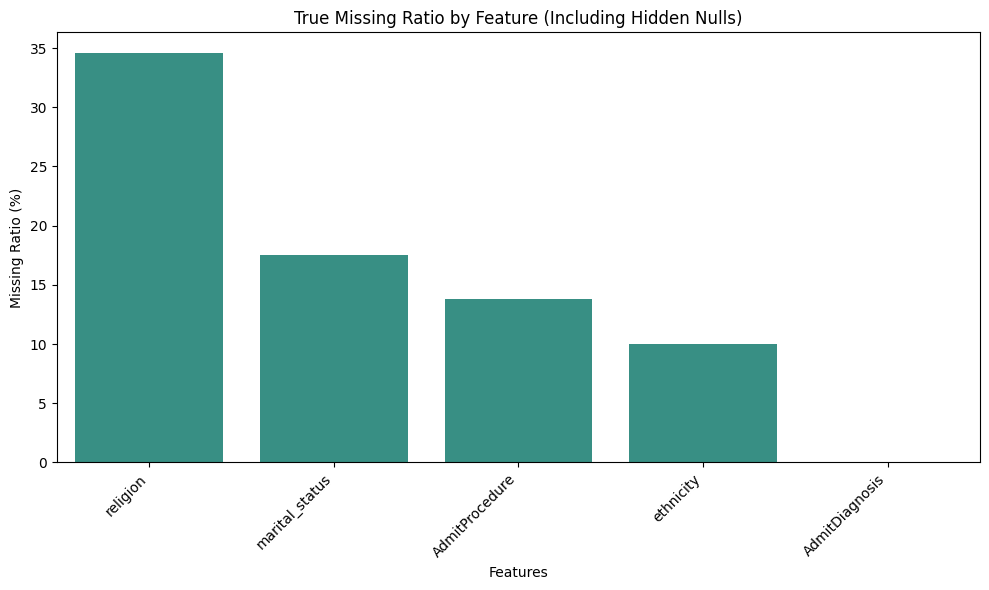

In [19]:
missing_ratio = (train_df.isnull().mean() * 100).sort_values(ascending=False)
missing_ratio = missing_ratio[missing_ratio > 0]

plt.figure(figsize=(10, 6))
sns.barplot(x=missing_ratio.index, y=missing_ratio.values, color="#2a9d8f")

plt.xticks(rotation=45, ha="right")
plt.ylabel("Missing Ratio (%)")
plt.xlabel("Features")
plt.title("True Missing Ratio by Feature (Including Hidden Nulls)")
plt.tight_layout()

missing_plot_path = os.path.join(output_dir, 'missing_value_ratio.jpg')
plt.savefig(missing_plot_path, dpi=200, bbox_inches='tight')
print(f"Saved figure: {missing_plot_path}")
print(f"圖一:")
plt.show()

缺失值處理方法

1. marital_status的缺失值與 age = 0 高度相關
在 marital_status 的 8247 筆缺失值中，有高達 6107 筆的病患年齡為 age = 0 (NEWBORN)。

處理方法：若 age = 0，將缺失的婚姻狀況填補為 "NEWBORN"，其餘的 Nan 填補為 "UNKNOWN"。

2. 雖然原始 AdmitProcedure 欄位沒有任何 Nan，但實際上它包含了 6500 筆的字串 "na"。

處理方法：將字串 "na" 替換為 "NO_PROCEDURE"。

3. religion, ethnicity 

處理方法：為了提升資料品質並減少雜訊，將上述這類「未指定」、「無法取得」或「拒絕回答」的類別，統一合併命名為 "UNKNOWN" 類別。

4. AdmitDiagnosis 

處理方法：缺失數量占比非常小，並且臨床診斷對於病患最終存活具有一定程度的重要性，難以透過現有數據進行補齊，因此在這裡選擇drop。

In [20]:
# marital_status 缺失值的年齡分布，觀察到年齡在0歲(NEWBORN)具有大量缺失值，所以 marital_status 不適合直接drop掉。
print(f"Missing Marital Status: {train_df['marital_status'].isnull().sum()}")
print("Missing Marital Status (Age Distribution)")
missing_marital_age_stats = train_df[train_df['marital_status'].isnull()]['age'].value_counts().head(10)
print(f"\n表二:")
missing_marital_age_stats

Missing Marital Status: 8247
Missing Marital Status (Age Distribution)

表二:


age
0     6107
52      79
83      58
70      52
81      50
75      49
73      49
79      48
53      48
50      47
Name: count, dtype: int64

In [21]:
# marital_status missing values (if age=0 fill with "NEWBORN", else fill with "UNKNOWN")
train_df.loc[(train_df['age'] == 0) & (train_df['marital_status'].isnull()), 'marital_status'] = "NEWBORN"
train_df['marital_status'] = train_df['marital_status'].fillna("UNKNOWN")

# AdmitProcedure missing values (fill with "NO_PROCEDURE")
train_df['AdmitProcedure'] = train_df['AdmitProcedure'].fillna("NO_PROCEDURE")

# religion missing values (fill with "UNKNOWN")
train_df['religion'] = train_df['religion'].fillna('UNKNOWN')

# ethnicity missing values (fill with "UNKNOWN")
train_df['ethnicity'] = train_df['ethnicity'].fillna('UNKNOWN')

# AdmitDiagnosis missing values (drop rows with missing AdmitDiagnosis)
train_df.dropna(subset=['AdmitDiagnosis'], inplace=True)

In [22]:
print("After processed missing values in train_df:")
get_missing_features(train_df)

After processed missing values in train_df:


Series([], dtype: int64)

In [23]:
# 對 test_df 套用與 train_df 相同的缺失值處理
religion_nulls = ['NOT SPECIFIED', 'UNOBTAINABLE']
ethnicity_nulls = ['UNKNOWN/NOT SPECIFIED', 'UNABLE TO OBTAIN', 'PATIENT DECLINED TO ANSWER']

test_df['AdmitProcedure'] = test_df['AdmitProcedure'].replace('na', np.nan)
test_df['religion'] = test_df['religion'].replace(religion_nulls, np.nan)
test_df['ethnicity'] = test_df['ethnicity'].replace(ethnicity_nulls, np.nan)
test_df['marital_status'] = test_df['marital_status'].replace('UNKNOWN (DEFAULT)', np.nan)

test_df.loc[(test_df['age'] == 0) & (test_df['marital_status'].isnull()), 'marital_status'] = 'NEWBORN'
test_df['marital_status'] = test_df['marital_status'].fillna('UNKNOWN')
test_df['AdmitProcedure'] = test_df['AdmitProcedure'].fillna('NO_PROCEDURE')
test_df['religion'] = test_df['religion'].fillna('UNKNOWN')
test_df['ethnicity'] = test_df['ethnicity'].fillna('UNKNOWN')

test_df.dropna(subset=['AdmitDiagnosis'], inplace=True)

print('After processed missing values in test_df:')
get_missing_features(test_df)

After processed missing values in test_df:


Series([], dtype: int64)

分佈摘要與初步觀察

連續變數分佈

Saved figure: ./output\distribution_plots.jpg
圖二:


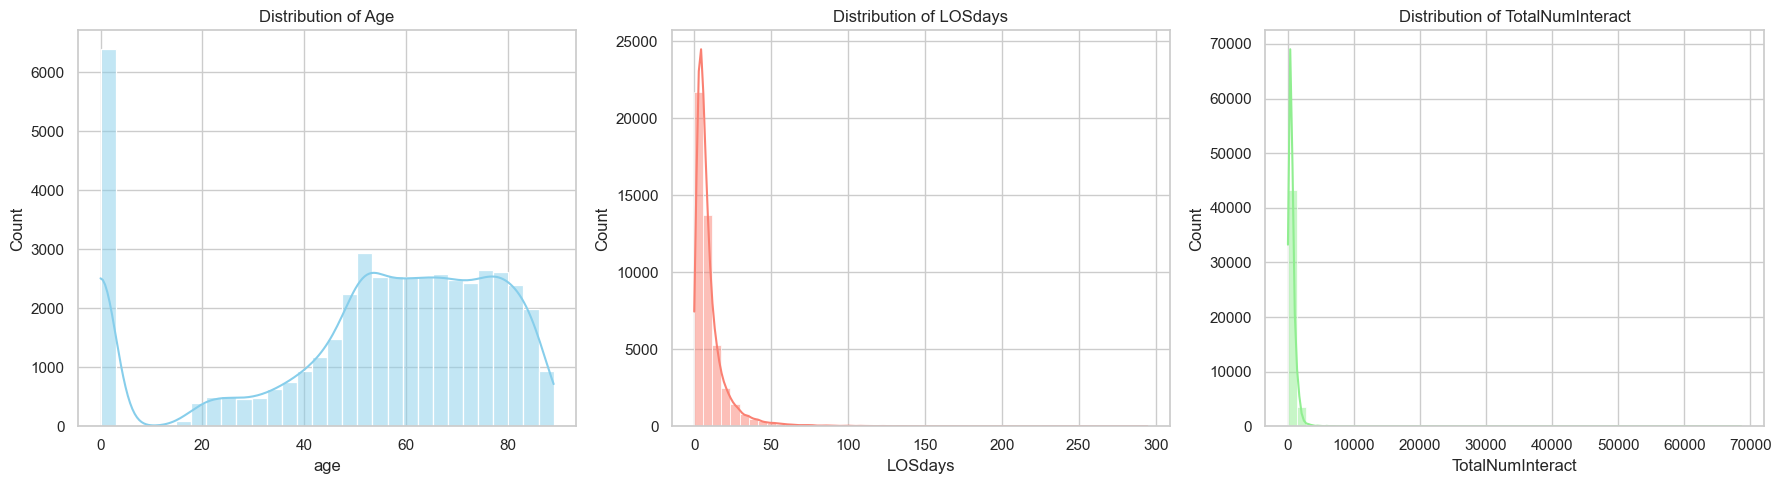

In [24]:
# Set global visual style
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Age distribution (雙峰分布)
sns.histplot(data=train_df, x='age', bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Age')

# LOSdays distribution (右偏分布)
sns.histplot(data=train_df, x='LOSdays', bins=50, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of LOSdays')

# TotalNumInteract distribution (右偏分布，部分病人有非常多的醫療互動)
sns.histplot(data=train_df, x='TotalNumInteract', bins=50, kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of TotalNumInteract')

plt.tight_layout()
distribution_plot_path = os.path.join(output_dir, 'distribution_plots.jpg')
plt.savefig(distribution_plot_path, dpi=200, bbox_inches='tight')
print(f"Saved figure: {distribution_plot_path}")
print(f"圖二:")
plt.show()

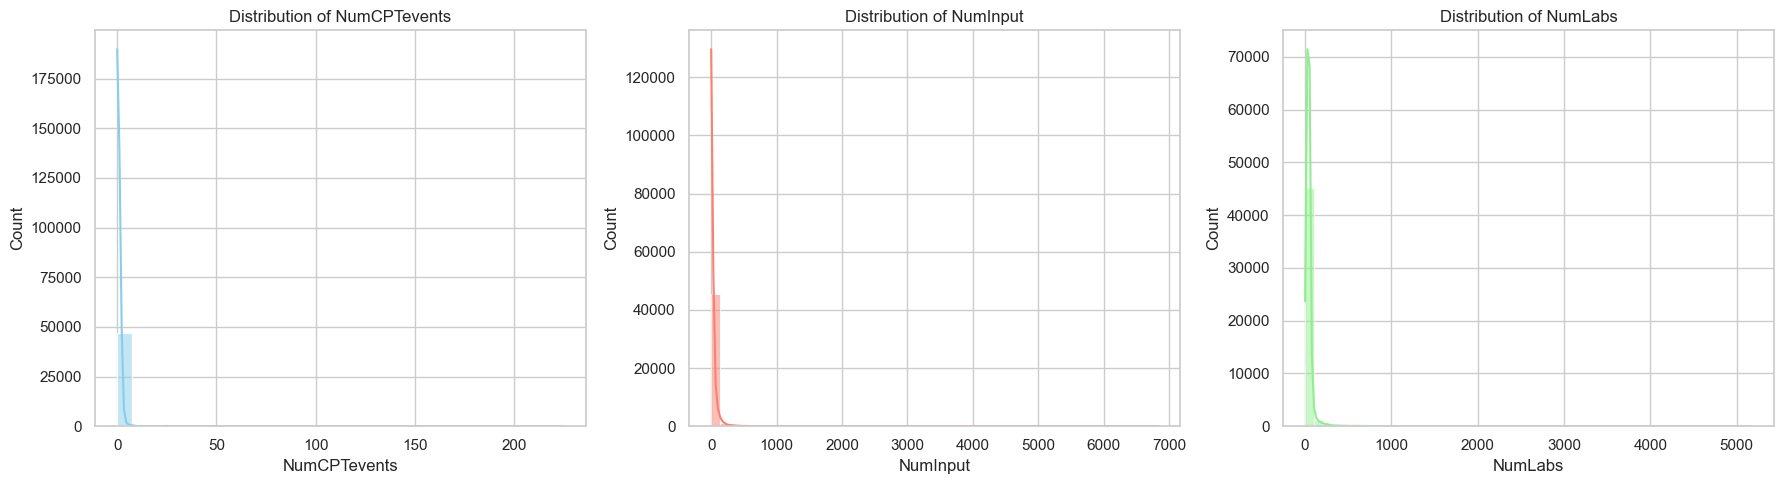

In [25]:
# Set global visual style
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# NumCPTevents distribution (右偏分布)
sns.histplot(data=train_df, x='NumCPTevents', bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of NumCPTevents')

# NumInput distribution (右偏分布)
sns.histplot(data=train_df, x='NumInput', bins=50, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of NumInput')

# NumLabs distribution (右偏分布)
sns.histplot(data=train_df, x='NumLabs', bins=50, kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of NumLabs')


plt.tight_layout()
plt.show()

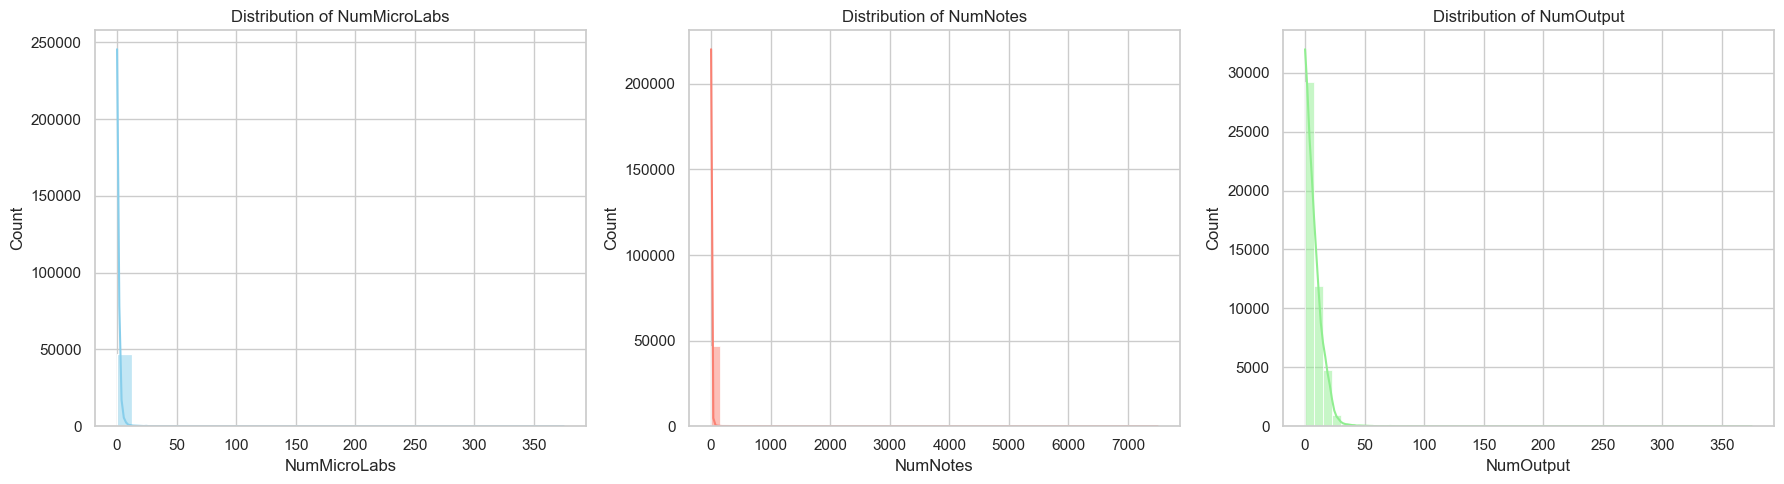

In [26]:
# Set global visual style
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# NumMicroLabs distribution (右偏分布)
sns.histplot(data=train_df, x='NumMicroLabs', bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of NumMicroLabs')

# NumNotes distribution (右偏分布)
sns.histplot(data=train_df, x='NumNotes', bins=50, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of NumNotes')

# NumOutput distribution (右偏分布)
sns.histplot(data=train_df, x='NumOutput', bins=50, kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of NumOutput')

plt.tight_layout()
plt.show()

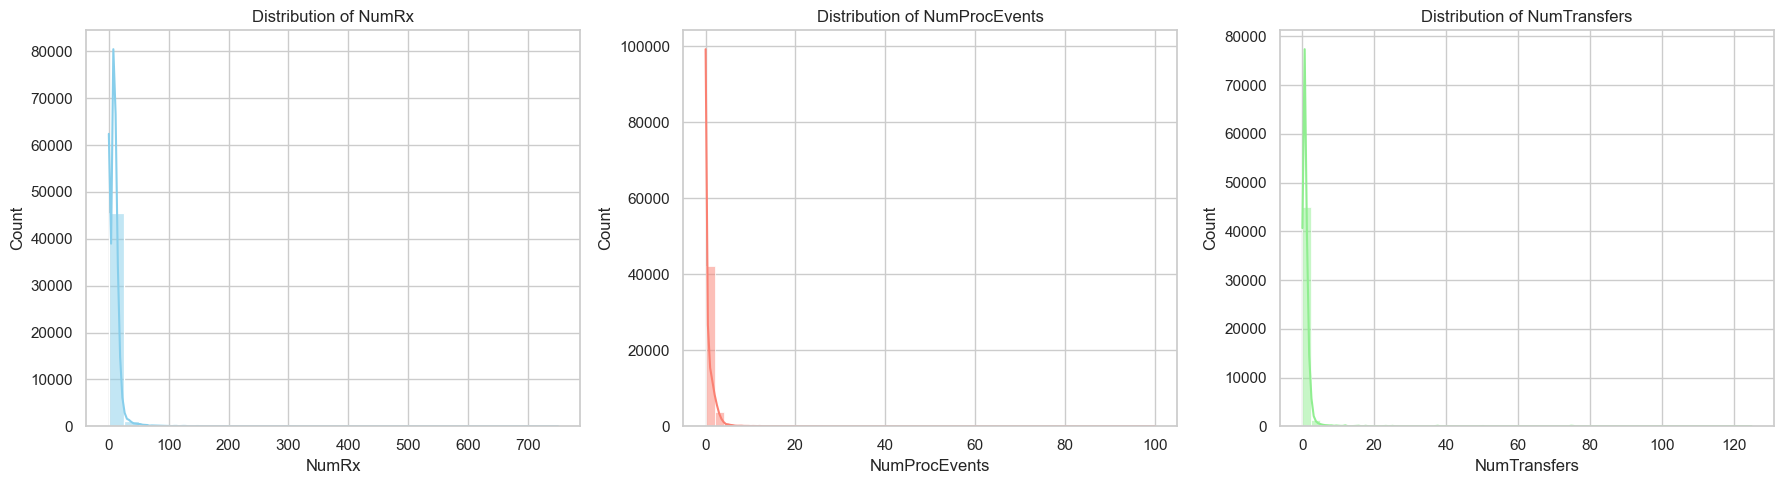

In [27]:
# Set global visual style
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# NumRx distribution (右偏分布)
sns.histplot(data=train_df, x='NumRx', bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of NumRx')

# NumProcEvents distribution (右偏分布)
sns.histplot(data=train_df, x='NumProcEvents', bins=50, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of NumProcEvents')

# NumTransfers distribution (右偏分布)
sns.histplot(data=train_df, x='NumTransfers', bins=50, kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of NumTransfers')

plt.tight_layout()
plt.show()

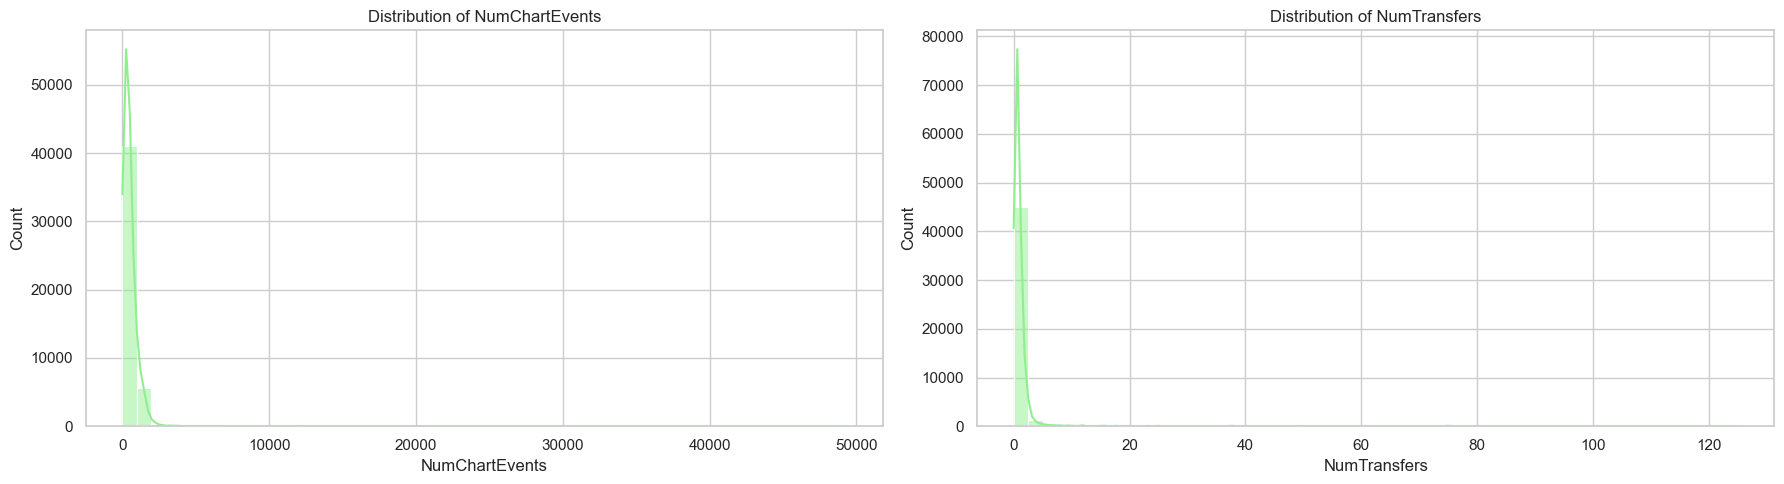

In [28]:
# Set global visual style
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(18, 5))


# NumChartEvents distribution (右偏分布)
sns.histplot(data=train_df, x='NumChartEvents', bins=50, kde=True, ax=axes[0], color='lightgreen')
axes[0].set_title('Distribution of NumChartEvents')

# NumTransfers distribution (右偏分布)
sns.histplot(data=train_df, x='NumTransfers', bins=50, kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Distribution of NumTransfers')

plt.tight_layout()
plt.show()

類別變數與預測目標關係

1. admit_type
從圖表中可看出， EMERGENCY 佔據了絕大多數的資料量，且橘色區塊(死亡 ExpiredHospital = 1)的相對比例明顯比 ELECTIVE 來得高。

2. LOSgroupNum 
各個住院天數組別的存活與死亡比例分佈。住院天數1與4的群組，包含相對高的死亡個案，推測可能原因為住院天數極短(症狀嚴重導致死亡)以及住院天數極長(需要即時長期關注之病患，症狀嚴重)。

Saved figure: ./output\expired_hospital.jpg
圖三:


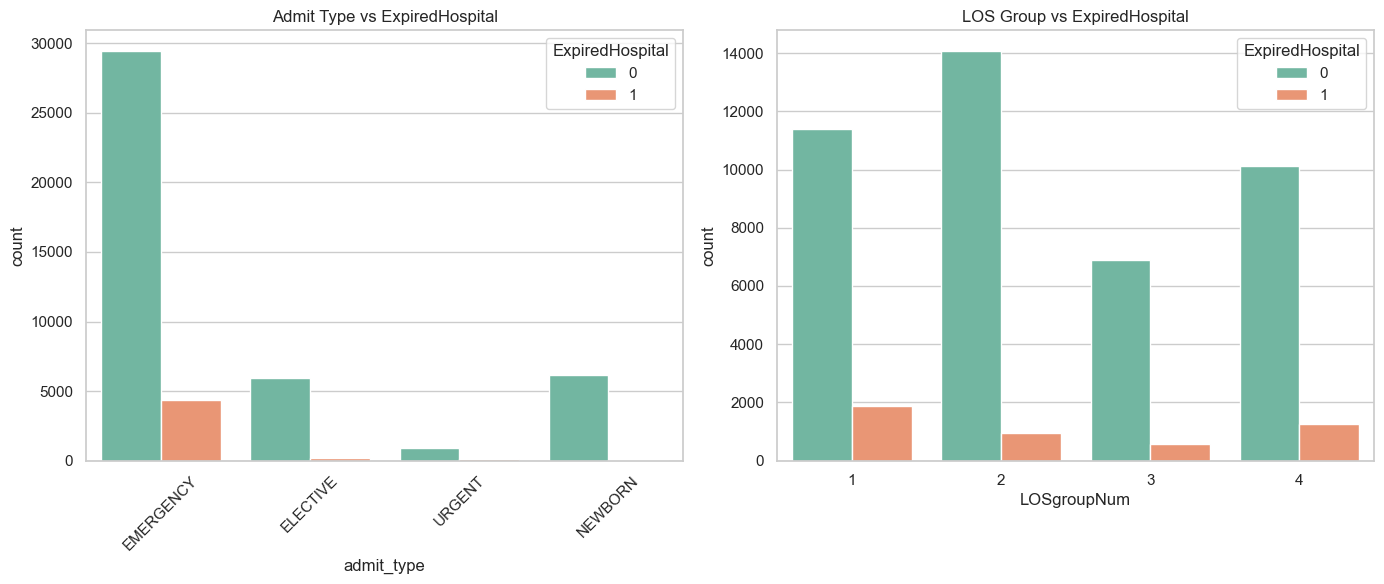

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Admit type vs ExpiredHospital
sns.countplot(data=train_df, x='admit_type', hue='ExpiredHospital', ax=axes[0], palette='Set2')
axes[0].set_title('Admit Type vs ExpiredHospital')
axes[0].tick_params(axis='x', rotation=45)

# LOS group vs ExpiredHospital
sns.countplot(data=train_df, x='LOSgroupNum', hue='ExpiredHospital', ax=axes[1], palette='Set2')
axes[1].set_title('LOS Group vs ExpiredHospital')
# axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
expired_relation_plot_path = os.path.join(output_dir, 'expired_hospital.jpg')
plt.savefig(expired_relation_plot_path, dpi=200, bbox_inches='tight')
print(f"Saved figure: {expired_relation_plot_path}")
print(f"圖三:")
plt.show()

In [30]:
# ===== 資料集重點統計表 (使用 groupby().agg()) =====

# 1. 按性別分組的統計
print(f"--" * 50)
print("表三：按性別分組的重點統計")
print(f"--" * 50)
gender_stats = train_df.groupby('gender').agg(
    患者數量=('hadm_id', 'count'),
    平均年齡=('age', 'mean'),
    平均住院天數=('LOSdays', 'mean'),
    平均診斷數=('NumDiagnosis', 'mean'),
    平均化驗數=('NumLabs', 'mean'),
    死亡人數=('ExpiredHospital', lambda x: (x > 0).sum()),
    死亡率百分比=('ExpiredHospital', lambda x: (x > 0).sum() / len(x) * 100)
).round(2)
gender_stats

# print(gender_stats)
# print()

----------------------------------------------------------------------------------------------------
表三：按性別分組的重點統計
----------------------------------------------------------------------------------------------------


,患者數量,平均年齡,平均住院天數,平均診斷數,平均化驗數,死亡人數,死亡率百分比
gender,,,,,,,
F,20661,53.49,9.95,2.67,45.33,2149,10.40
M,26499,52.97,10.21,2.74,47.47,2533,9.56


In [31]:
# 2. 按入院類型分組的統計
print(f"--" * 50)
print("表四：按入院類型分組的重點統計")
print(f"--" * 50)
admit_type_stats = train_df.groupby('admit_type').agg(
    患者數量=('hadm_id', 'count'),
    平均年齡=('age', 'mean'),
    平均住院天數=('LOSdays', 'mean'),
    平均診斷數=('NumDiagnosis', 'mean'),
    死亡人數=('ExpiredHospital', lambda x: (x > 0).sum()),
    死亡率百分比=('ExpiredHospital', lambda x: (x > 0).sum() / len(x) * 100)
).round(2).sort_values('患者數量', ascending=False)
admit_type_stats

# print(admit_type_stats)
# print()

----------------------------------------------------------------------------------------------------
表四：按入院類型分組的重點統計
----------------------------------------------------------------------------------------------------


,患者數量,平均年齡,平均住院天數,平均診斷數,死亡人數,死亡率百分比
admit_type,,,,,,
EMERGENCY,33798,60.97,10.01,2.90,4350,12.87
NEWBORN,6186,0.00,11.42,2.48,49,0.79
ELECTIVE,6131,62.58,8.86,2.03,157,2.56
URGENT,1045,61.62,12.52,1.76,126,12.06


In [32]:
# 3. 按種族分組的統計
print(f"--" * 50)
print("表五：按種族分組的重點統計")
print(f"--" * 50)
ethnicity_stats = train_df.groupby('ethnicity').agg(
    患者數量=('hadm_id', 'count'),
    平均年齡=('age', 'mean'),
    平均住院天數=('LOSdays', 'mean'),
    平均診斷數=('NumDiagnosis', 'mean'),
    平均線上互動數=('NumChartEvents', 'mean'),
    死亡人數=('ExpiredHospital', lambda x: (x > 0).sum()),
    死亡率百分比=('ExpiredHospital', lambda x: (x > 0).sum() / len(x) * 100)
).round(2).sort_values('患者數量', ascending=False)
ethnicity_stats

# print(ethnicity_stats)
# print()

----------------------------------------------------------------------------------------------------
表五：按種族分組的重點統計
----------------------------------------------------------------------------------------------------


,患者數量,平均年齡,平均住院天數,平均診斷數,平均線上互動數,死亡人數,死亡率百分比
ethnicity,,,,,,,
WHITE,32839,55.19,10.09,2.70,531.15,3256,9.92
UNKNOWN,4713,56.03,10.33,2.88,619.09,742,15.74
BLACK/AFRICAN AMERICAN,4284,48.13,10.24,2.77,463.89,321,7.49
HISPANIC OR LATINO,1359,41.08,9.94,2.56,478.71,81,5.96
OTHER,1225,42.41,10.48,2.81,532.04,91,7.43
ASIAN,1191,30.48,8.82,2.02,362.54,78,6.55
ASIAN - CHINESE,217,54.82,9.37,3.02,450.63,22,10.14
HISPANIC/LATINO - PUERTO RICAN,190,53.49,9.09,2.68,560.95,11,5.79
BLACK/CAPE VERDEAN,158,49.70,8.89,3.78,472.71,10,6.33


In [33]:
# 4. 按結果（是否死亡）分組的統計
print(f"--" * 50)
print("表六：按院內結果分組的重點統計")
print(f"--" * 50)
result_stats = train_df.groupby('ExpiredHospital').agg(
    患者數量=('hadm_id', 'count'),
    占比百分比=('hadm_id', lambda x: len(x) / len(train_df) * 100),
    平均年齡=('age', 'mean'),
    平均住院天數=('LOSdays', 'mean'),
    平均診斷數=('NumDiagnosis', 'mean'),
    平均檢查數=('NumProcs', 'mean'),
    平均臨床事件數=('NumChartEvents', 'mean')
).round(2)
result_stats

# print(result_stats)
# print()

----------------------------------------------------------------------------------------------------
表六：按院內結果分組的重點統計
----------------------------------------------------------------------------------------------------


,患者數量,占比百分比,平均年齡,平均住院天數,平均診斷數,平均檢查數,平均臨床事件數
ExpiredHospital,,,,,,,
0,42478,90.07,51.84,10.09,2.18,0.61,458.54
1,4682,9.93,65.50,10.17,7.54,2.52,1146.64


In [34]:
obs_list = {}

# 1. 急診 + LOSdays >= 7
cond1 = (train_df['admit_type'] == 'EMERGENCY') & (train_df['LOSdays'] >= 7)
obs_list['Emergency+LOSdays>=7'] = int(cond1.sum())
obs_list['Emergency+LOSdays>=7 (%)'] = round(float((train_df.loc[cond1, 'ExpiredHospital'] == 1).mean() * 100), 3)

# 2. 非急診 + LOSdays >= 7
cond2 = (train_df['admit_type'] != 'EMERGENCY') & (train_df['LOSdays'] >= 7)
obs_list['Non-Emergency+LOSdays>=7'] = int(cond2.sum())
obs_list['Non-Emergency+LOSdays>=7 (%)'] = round(float((train_df.loc[cond2, 'ExpiredHospital'] == 1).mean() * 100), 3)

# 3. 年齡 >= 65
cond3 = train_df['age'] >= 65
obs_list['Age>=65'] = int(cond3.sum())
obs_list['Age>=65 (%)'] = round(float((train_df.loc[cond3, 'ExpiredHospital'] == 1).mean() * 100), 3)

# 4. 年齡 < 65
cond4 = train_df['age'] < 65
obs_list['Age<65'] = int(cond4.sum())
obs_list['Age<65 (%)'] = round(float((train_df.loc[cond4, 'ExpiredHospital'] == 1).mean() * 100), 3)

# 5. 男女性別死亡率
cond5_m = train_df['gender'] == 'M'
cond5_f = train_df['gender'] == 'F'
obs_list['Male'] = int(cond5_m.sum())
obs_list['Male (%)'] = round(float((train_df.loc[cond5_m, 'ExpiredHospital'] == 1).mean() * 100), 3)
obs_list['Female'] = int(cond5_f.sum())
obs_list['Female (%)'] = round(float((train_df.loc[cond5_f, 'ExpiredHospital'] == 1).mean() * 100), 3)

# 6. 住院天數分層：LOSdays >= 10 vs < 10
cond6_hi = train_df['LOSdays'] >= 10
cond6_lo = train_df['LOSdays'] < 10
obs_list['LOSdays>=10'] = int(cond6_hi.sum())
obs_list['LOSdays>=10 (%)'] = round(float((train_df.loc[cond6_hi, 'ExpiredHospital'] == 1).mean() * 100), 3)
obs_list['LOSdays<10'] = int(cond6_lo.sum())
obs_list['LOSdays<10 (%)'] = round(float((train_df.loc[cond6_lo, 'ExpiredHospital'] == 1).mean() * 100), 3)

# 7. 互動量高低：TotalNumInteract 前 25% vs 後 25%
q75 = train_df['TotalNumInteract'].quantile(0.75)
q25 = train_df['TotalNumInteract'].quantile(0.25)
cond7_hi = train_df['TotalNumInteract'] >= q75
cond7_lo = train_df['TotalNumInteract'] <= q25
obs_list['TotalNumInteract>=q75'] = int(cond7_hi.sum())
obs_list['TotalNumInteract>=q75 (%)'] = round(float((train_df.loc[cond7_hi, 'ExpiredHospital'] == 1).mean() * 100), 3)
obs_list['TotalNumInteract<q25'] = int(cond7_lo.sum())
obs_list['TotalNumInteract<q25 (%)'] = round(float((train_df.loc[cond7_lo, 'ExpiredHospital'] == 1).mean() * 100), 3)


# dataframe 處理
conditions = []
counts = []
mortality_rates = []

for key, value in obs_list.items():
    if key.endswith(' (%)'):
        mortality_rates.append(value)
    else:
        conditions.append(key)
        counts.append(value)

df_obs = pd.DataFrame({
    'Observation Group': conditions,
    'Patient Count': counts,
    'ExpiredHospital (%)': mortality_rates
})
print(f"表七")
df_obs

表七


,Observation Group,Patient Count,ExpiredHospital (%)
0,Emergency+LOSdays>=7,16494,11.265
1,Non-Emergency+LOSdays>=7,5287,3.423
2,Age>=65,18903,14.082
3,Age<65,28257,7.149
4,Male,26499,9.559
5,Female,20661,10.401
6,LOSdays>=10,14421,10.519
7,LOSdays<10,32739,9.667
8,TotalNumInteract>=q75,11790,28.193
9,TotalNumInteract<q25,11790,3.376


前處理與特徵處理

編碼與標準化

In [35]:
# 1. 準備特徵與標籤（drop target + hadm_id）
X_train = train_df.drop(columns=[target_col, 'hadm_id'])
X_test = test_df.drop(columns=[target_col, 'hadm_id'])
y_train = train_df[target_col]
y_test = test_df[target_col]

# 匯出前的原始特徵快照（transform 前）
df_feature = X_train.reset_index(drop=True).copy()

# 2. 右偏分佈特徵：log transform + 標準化
num_log_cols = [col for col in X_train.columns if col.startswith('Num') or col in ['TotalNumInteract', 'LOSdays']]

# 3. 正常/雙峰分佈特徵：標準化
num_std_cols = ['age']

# 4. 類別特徵 (Target Encoding)
target_cats = ['AdmitDiagnosis', 'AdmitProcedure', 'ethnicity', 'religion', 'admit_location']

# 5. 類別特徵 (One-Hot Encoding)
one_hot_cats = ['gender', 'admit_type', 'marital_status', 'insurance']

# 6. 類別特徵 (Ordinal)
ordinal_cats = ['LOSgroupNum']

# 7. transform pipelines
log1p_transformer = Pipeline(steps=[
    ('log1p', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num_log', log1p_transformer, num_log_cols),
        ('num_std', StandardScaler(), num_std_cols + ordinal_cats),
        ('cat_target', TargetEncoder(target_type='binary'), target_cats),
        ('cat_ohe', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), one_hot_cats)
    ],
    remainder='drop'
)

print('===== Unknown Categories Check (for OneHotEncoder) =====')
unknown_report = {}
for idx, col in enumerate(one_hot_cats):
    train_cats = set(X_train[col].fillna('__MISSING__').astype(str).unique())
    test_cats = set(X_test[col].fillna('__MISSING__').astype(str).unique())
    unknown_cats = sorted(test_cats - train_cats)
    if unknown_cats:
        unknown_report[col] = unknown_cats
        print(f'Column index [{idx}] -> {col}: {unknown_cats}')

if not unknown_report:
    print('No unknown categories in OneHotEncoder columns.')
print()

# 8. fit + transform
X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_test_processed = preprocessor.transform(X_test)

# 9. 取得轉換後欄位名
onehot_feature_names = preprocessor.named_transformers_['cat_ohe'].get_feature_names_out(one_hot_cats)
all_feature_names = num_log_cols + num_std_cols + ordinal_cats + target_cats + list(onehot_feature_names)

# 10. 轉回 DataFrame
X_train_df = pd.DataFrame(X_train_processed, columns=all_feature_names, index=X_train.index)
X_test_df = pd.DataFrame(X_test_processed, columns=all_feature_names, index=X_test.index)

print(f'Original feature shape (before transform): {X_train.shape}')
print(f'Processed feature shape (after transform): {X_train_df.shape}')
print('Processed features ready for integrated feature engineering!')

===== Unknown Categories Check (for OneHotEncoder) =====
No unknown categories in OneHotEncoder columns.

Original feature shape (before transform): (47160, 26)
Processed feature shape (after transform): (47160, 37)
Processed features ready for integrated feature engineering!


In [36]:
X_train_df

,LOSdays,NumCallouts,NumDiagnosis,NumProcs,NumCPTevents,NumInput,NumLabs,NumMicroLabs,NumNotes,NumOutput,...,marital_status_MARRIED,marital_status_NEWBORN,marital_status_SEPARATED,marital_status_SINGLE,marital_status_UNKNOWN,marital_status_WIDOWED,insurance_Medicaid,insurance_Medicare,insurance_Private,insurance_Self Pay
39297,0.193944,-0.697307,0.097844,-0.263912,0.532274,0.794855,0.462373,-0.153217,-0.243103,1.297759,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
50580,-1.097705,-0.697307,0.056295,1.846859,-1.250117,-1.915104,-0.469999,-1.019883,-0.233566,-1.767829,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
113,-0.905490,-0.697307,-0.428363,-1.041488,0.602108,0.950454,0.678026,0.575191,0.172725,-0.572361,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
32840,0.901737,-0.697307,-1.019697,-0.451121,0.385175,0.057766,-0.002582,-1.019883,-0.616309,-0.517597,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
28253,1.547965,-0.697307,-0.845955,0.195416,1.123510,1.588863,0.985480,1.108561,-0.416663,1.330751,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18565,-2.571606,-0.697307,-1.651973,-1.041488,-1.250117,-1.915104,-3.876658,-1.019883,-0.681221,-1.767829,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
20508,-0.230929,0.639109,-0.030036,-0.282007,-0.335876,-1.026218,0.242225,-0.232569,-0.373742,-0.129171,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
55994,-0.145423,0.570391,-0.231576,-0.318600,-0.922593,-1.915104,0.070868,-1.019883,-0.416663,-1.767829,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
37859,1.295996,0.360656,-0.420350,-0.337102,0.469191,0.334446,-0.091244,0.225338,-0.667983,0.958450,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [37]:
# ========================================
# 整合：AUROC + Feature Construction + PCA
# ========================================

# (A) 單變量 AUROC（僅診斷訊號，不直接刪欄）
num_cols = X_train_df.select_dtypes(include=[np.number]).columns.tolist()
auroc_list = []
for col in num_cols:
    tr = pd.to_numeric(X_train_df[col], errors='coerce')
    if tr.notna().nunique() <= 1:
        continue
    tr_fill = tr.fillna(tr.median())
    try:
        auc = roc_auc_score(y_train, tr_fill)
        auc = max(auc, 1 - auc)
        auroc_list.append((col, auc))
    except Exception:
        pass

auroc_df = pd.DataFrame(auroc_list, columns=['feature', 'auroc']).sort_values('auroc', ascending=False)
selected_num_features = auroc_df[auroc_df['auroc'] >= 0.55]['feature'].tolist()

# (B) Feature Construction
for d in [X_train_df, X_test_df]:
    d['resource_intensity'] = d['TotalNumInteract'] / (d['LOSdays'] + 1.0)
    d['long_LOS_flag'] = (d['LOSdays'] >= 7).astype(int)
    d['complexity_score'] = d[['NumDiagnosis', 'NumProcs', 'NumLabs']].sum(axis=1)

constructed_features = ['resource_intensity', 'long_LOS_flag', 'complexity_score']

# (C) PCA
num_count_cols = [c for c in X_train_df.columns if c.startswith('Num')]
num_count_cols = [c for c in num_count_cols if c in X_test_df.columns]

train_count = X_train_df[num_count_cols].apply(pd.to_numeric, errors='coerce')
test_count = X_test_df[num_count_cols].apply(pd.to_numeric, errors='coerce')

med = train_count.median()
train_count = train_count.fillna(med)
test_count = test_count.fillna(med)

scaler_pca = StandardScaler()
train_count_z = scaler_pca.fit_transform(train_count)
test_count_z = scaler_pca.transform(test_count)

pca = PCA(n_components=2, random_state=random_seed)
train_pca = pca.fit_transform(train_count_z)
test_pca = pca.transform(test_count_z)

# 先移除原始 Num* 欄位，再加入 PCA1/2，才是實際降維
X_train_df = X_train_df.drop(columns=num_count_cols)
X_test_df = X_test_df.drop(columns=num_count_cols)

X_train_df['NumPCA1'] = train_pca[:, 0]
X_train_df['NumPCA2'] = train_pca[:, 1]
X_test_df['NumPCA1'] = test_pca[:, 0]
X_test_df['NumPCA2'] = test_pca[:, 1]

# 最終供模型使用
X_train_engineered = X_train_df.copy()
X_test_engineered = X_test_df.copy()

# 建立 df_model_ready（索引重置後再 concat，避免列數錯位）
df_model_ready = pd.concat(
    [X_train_engineered.reset_index(drop=True), y_train.reset_index(drop=True).rename('target')],
    axis=1
)

print('===== Integrated Feature Engineering Summary =====')
print(f'AUROC-selected numeric features (>=0.55): {len(selected_num_features)}')
print('Constructed features:', constructed_features)
print(f'Num* columns used for PCA: {len(num_count_cols)}')
print('PCA explained variance ratio:', np.round(pca.explained_variance_ratio_, 4))
print('PCA cumulative explained variance:', round(float(pca.explained_variance_ratio_.sum()), 4))
print()
print('Model input shape check:')
print('X_train_engineered:', X_train_engineered.shape)
print('X_test_engineered :', X_test_engineered.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)
print('df_feature (before transform):', df_feature.shape)
print('df_model_ready (after transform):', df_model_ready.shape)

df_model_ready.head()

===== Integrated Feature Engineering Summary =====
AUROC-selected numeric features (>=0.55): 0
Constructed features: ['resource_intensity', 'long_LOS_flag', 'complexity_score']
Num* columns used for PCA: 13
PCA explained variance ratio: [0.3607 0.2019]
PCA cumulative explained variance: 0.5626

Model input shape check:
X_train_engineered: (47160, 29)
X_test_engineered : (11791, 29)
y_train: (47160,)
y_test : (11791,)
df_feature (before transform): (47160, 26)
df_model_ready (after transform): (47160, 30)


,LOSdays,TotalNumInteract,age,LOSgroupNum,AdmitDiagnosis,AdmitProcedure,ethnicity,religion,admit_location,gender_M,...,insurance_Medicaid,insurance_Medicare,insurance_Private,insurance_Self Pay,resource_intensity,long_LOS_flag,complexity_score,NumPCA1,NumPCA2,target
0,0.193944,0.918461,0.724509,0.566996,0.099290,0.152813,0.159640,0.092561,0.128889,1.0,...,0.0,0.0,1.0,0.0,0.769266,0,0.296305,0.856231,-1.590597,0
1,-1.097705,-2.082974,0.955714,-1.203249,0.099290,0.130529,0.074189,0.093826,0.027920,0.0,...,0.0,1.0,0.0,0.0,21.319003,0,1.433156,-2.617700,3.575590,0
2,-0.905490,0.199560,-0.470052,-1.203249,0.007221,0.073026,0.099299,0.104848,0.137144,0.0,...,0.0,0.0,1.0,0.0,2.111525,0,-0.791825,0.520392,-0.654597,0
3,0.901737,-0.753830,0.685975,1.452119,0.142266,0.026499,0.098626,0.088989,0.026954,1.0,...,0.0,1.0,0.0,0.0,-0.396391,0,-1.473401,-1.419629,-0.780168,0
4,1.547965,1.111698,0.994248,1.452119,0.099290,0.015375,0.099357,0.094164,0.135213,1.0,...,0.0,1.0,0.0,0.0,0.436308,0,0.334941,1.616272,-2.438960,1


In [38]:
# df_model_ready 檢查
print('DataFrame Model Ready (Training Set):')
print(f'Shape: {df_model_ready.shape}')
print(f'Columns: {len(df_model_ready.columns)}')
print(f'Target distribution:\n{df_model_ready["target"].value_counts()}')
print(df_model_ready.head())

DataFrame Model Ready (Training Set):
Shape: (47160, 30)
Columns: 30
Target distribution:
target
0    42478
1     4682
Name: count, dtype: int64
    LOSdays  TotalNumInteract       age  LOSgroupNum  AdmitDiagnosis  \
0  0.193944          0.918461  0.724509     0.566996        0.099290   
1 -1.097705         -2.082974  0.955714    -1.203249        0.099290   
2 -0.905490          0.199560 -0.470052    -1.203249        0.007221   
3  0.901737         -0.753830  0.685975     1.452119        0.142266   
4  1.547965          1.111698  0.994248     1.452119        0.099290   

   AdmitProcedure  ethnicity  religion  admit_location  gender_M  ...  \
0        0.152813   0.159640  0.092561        0.128889       1.0  ...   
1        0.130529   0.074189  0.093826        0.027920       0.0  ...   
2        0.073026   0.099299  0.104848        0.137144       0.0  ...   
3        0.026499   0.098626  0.088989        0.026954       1.0  ...   
4        0.015375   0.099357  0.094164        0.135213   

In [39]:
# ========================================
# 生成 EDA 關鍵統計表
# ========================================
# 蒐集所有 EDA 相關的關鍵統計數據供助教抽查

eda_stats = {}

# 1. 資料集基本訊息
eda_stats['數據集總行數'] = len(train_df)
eda_stats['數據集總列數'] = len(train_df.columns)

# 2. 目標變數分布
target_counts = train_df[target_col].value_counts()
eda_stats['目標變數-逝世(1)人數'] = int(target_counts.get(1, 0))
eda_stats['目標變數-存活(0)人數'] = int(target_counts.get(0, 0))
eda_stats['目標變數-逝世比例(%)'] = round(100 * target_counts.get(1, 0) / len(train_df), 2)

# 3. 缺失值統計
eda_stats['缺失值-AdmitDiagnosis'] = int((train_df['AdmitDiagnosis'] == 'na').sum()) if 'AdmitDiagnosis' in train_df.columns else 0
eda_stats['缺失值-marital_status'] = int((train_df['marital_status'] == 'UNKNOWN (DEFAULT)').sum()) if 'marital_status' in train_df.columns else 0
eda_stats['缺失值-religion'] = int(((train_df['religion'] == 'NOT SPECIFIED') | (train_df['religion'] == 'UNOBTAINABLE')).sum()) if 'religion' in train_df.columns else 0
eda_stats['缺失值-ethnicity'] = int(((train_df['ethnicity'] == 'UNKNOWN/NOT SPECIFIED') | (train_df['ethnicity'] == 'UNABLE TO OBTAIN') | (train_df['ethnicity'] == 'PATIENT DECLINED TO ANSWER')).sum()) if 'ethnicity' in train_df.columns else 0

# 4. 數值特徵基本統計
for col in ['age', 'LOSdays', 'TotalNumInteract']:
    if col in train_df.columns:
        eda_stats[f'{col}-均值'] = round(float(train_df[col].mean()), 2)
        eda_stats[f'{col}-中位數'] = round(float(train_df[col].median()), 2)
        eda_stats[f'{col}-標準差'] = round(float(train_df[col].std()), 2)
        eda_stats[f'{col}-最小值'] = round(float(train_df[col].min()), 2)
        eda_stats[f'{col}-最大值'] = round(float(train_df[col].max()), 2)

# 5. 類別特徵分布（前5大類別）
categorical_cols = ['gender', 'admit_type', 'AdmitDiagnosis', 'marital_status']
for col in categorical_cols:
    if col in train_df.columns:
        top_cats = train_df[col].value_counts().head(5)
        for idx, (cat, count) in enumerate(top_cats.items(), 1):
            eda_stats[f'{col}-Top{idx}'] = str(cat)
            eda_stats[f'{col}-Top{idx}_計數'] = int(count)

# 6. 整合 obs_list（至少 5 個具體可驗證觀察）
if 'obs_list' in globals() and isinstance(obs_list, dict):
    for k, v in obs_list.items():
        eda_stats[f'OBS-{k}'] = v

# 將統計轉換為 DataFrame
eda_key_stats = pd.DataFrame(list(eda_stats.items()), columns=['統計項目', '數值'])

print(f'EDA key stats total rows: {len(eda_key_stats)}')
eda_key_stats.head()

EDA key stats total rows: 76


,統計項目,數值
0,數據集總行數,47160
1,數據集總列數,28
2,目標變數-逝世(1)人數,4682
3,目標變數-存活(0)人數,42478
4,目標變數-逝世比例(%),9.93


In [40]:
# 自動輸出csv

# 1) transform 前特徵
feature_path = os.path.join(output_dir, 'df_feature.csv')
create_csv(feature_path, df_feature)

# 2) transform 後可直接建模資料（固定檔名：df_model_ready.csv）
df_model_ready_path = os.path.join(output_dir, 'df_model_ready.csv')
create_csv(df_model_ready_path, df_model_ready)

# 3) EDA 統計
a_stats_path = os.path.join(output_dir, 'eda_key_stats.csv')
create_csv(a_stats_path, eda_key_stats)


print('\n===== Final Model Input Shape Check =====')
print('X_train_engineered:', X_train_engineered.shape)
print('X_test_engineered :', X_test_engineered.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)


===== Final Model Input Shape Check =====
X_train_engineered: (47160, 29)
X_test_engineered : (11791, 29)
y_train: (47160,)
y_test : (11791,)
